# Implementation of Nulcear Recoil Yield on the WIMP sensitivity curve

with histograms instead of continous functions

## steps:

- 1. Get the diffrential rate of E_nr curve
- 2. translate it to histogram
- 3. get recoil yield curve
- 4. combine 2 & 3, make hist of differential rate of E_ee
- 5. modify the sensitivity code, and extract the curve 

In [ ]:
from analysis.sensitivity import scan_sensitivity
from analysis.rate_models import get_rate_ben
from analysis.dm_params import DMParams
from scipy.interpolate import interp1d
import numpy as np
import analysis.plotter as plotter
import matplotlib.pyplot as plt
import scipy.integrate as integrate
from scipy.integrate import quad


# DM model parameters in accordance with recommandation by (arxiv:2105.00599)
params = DMParams(m_D_GeV = 5,
                 sigma_pb = 0.1,
                 rho_GeV_cm3 = 0.3,
                 v0_kms = 230,
                 vE_kms = 250,
                 vesc_kms = 600,
                 exposure_kgdays = 11,
                 confidence_level = 0.9,
                 mass_number_A = 28,
                 c1 = 0.751, c2 = 0.561,
                 E_min_KeV= 0.63
                 )

## 1. Get the diffrential rate of E_nr curve

Text(0.5, 1.0, "Differential Rate (from Ben's Thesis)")

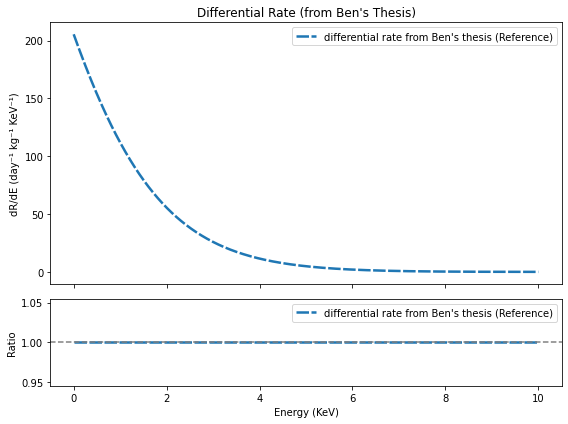

In [2]:
E_Rs_KeV = np.linspace(0.0001, 10, 1000)
dRs0 = [get_rate_ben(E, params) for E in E_Rs_KeV]
fig, axes = plotter.plot_differential_rate(E_Rs_KeV, [dRs0], ref_index = 0, 
                               labels=["differential rate from Ben's thesis"], panel_type= "ratio")
axes[0].set_title("Differential Rate (from Ben's Thesis)")
# axes[1].set_ylim(0, 5)

## 2. translate it to histogram


In [4]:
E_min, E_max = 0, 10   # Example range
bin_width = 0.5
bin_edges = np.arange(E_min, E_max + bin_width, bin_width)

In [8]:
hist_counts = []
for i in range(len(bin_edges)-1):
    val, _ = integrate.quad(lambda E: get_rate_ben(E, dm_params = params), bin_edges[i], bin_edges[i+1])
    hist_counts.append(val)
hist_counts = np.array(hist_counts)

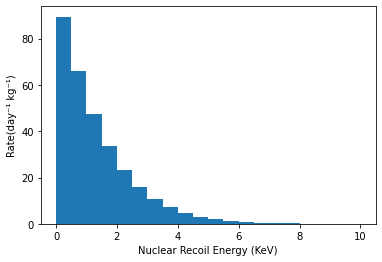

In [12]:
bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])
plt.bar(bin_centers, hist_counts, width=bin_width, align='center')
plt.xlabel("Nuclear Recoil Energy (KeV)")
plt.ylabel("Rate(day⁻¹ kg⁻¹)")
plt.show()

In [56]:
np.sum(hist_counts)

306.2032278210272

## 3. get recoil yield curve
use E_nr vs. E_ee plot

In [15]:
def lindhard(E_KeV, Z = 14):
    """ return the nuclear yield given by lindhard model (analycal)"""
    # lindhard model at k=0.146
    # input: nuclear recoil energy in KeV; atomic number of nuclear Z 
    # see also at Levin 5.1
    k = 0.146
    eta = 11.5 * E_KeV * Z ** (-7/3)
    g = 3 * eta ** 0.15 + 0.7 * eta ** 0.6 + eta
    nr_yield = k * g /(1 + k * g) # yield
    return nr_yield

In [ ]:
# other models to be added

## 4. combine 2 & 3, make hist of differential rate of E_ee


In [ ]:
E_nr_min, E_nr_max = 0.01, 30.0     # keVnr (example)
dE_nr = 0.01                       # fine recoil step for smooth remapping
E_nr = np.arange(E_nr_min, E_nr_max + dE_nr, dE_nr)

# Compute weights (expected counts per small recoil bin)
weights = get_rate_ben(E_nr,params) * dE_nr

# Map to ionized (measured) energy
E_ion = lindhard(E_nr) * E_nr   

# hist of E_ee
Eion_min, Eion_max = 0, 3 # Example range
Eion_width = 0.1
Eion_edges = np.arange(Eion_min, Eion_max + Eion_width, Eion_width)

hist_Eion, _ = np.histogram(E_ion, bins=Eion_edges, weights=weights)


In [54]:
hist_Eion

array([9.22605163e+01, 5.70995848e+01, 4.13450333e+01, 2.98380606e+01,
       2.20445658e+01, 1.62453521e+01, 1.16713536e+01, 8.87778164e+00,
       6.71312429e+00, 4.79709704e+00, 3.74443818e+00, 2.66685286e+00,
       2.08144621e+00, 1.51981060e+00, 1.11306815e+00, 8.64627762e-01,
       6.26606210e-01, 4.55141998e-01, 3.50817728e-01, 2.51177067e-01,
       1.85122121e-01, 1.31148332e-01, 9.82189963e-02, 6.76166391e-02,
       4.75017606e-02, 3.16189968e-02, 2.18745564e-02, 1.34862858e-02,
       8.37956204e-03, 4.39910698e-03])

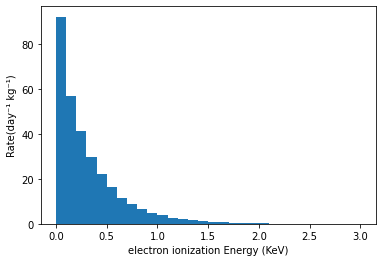

In [55]:
Eion_centers = 0.5 * (Eion_edges[1:] + Eion_edges[:-1])
plt.bar(Eion_centers, hist_Eion, width=Eion_width, align='center')
plt.xlabel("electron ionization Energy (KeV)")
plt.ylabel("Rate(day⁻¹ kg⁻¹)")
plt.show()

In [57]:
np.sum(hist_Eion)

305.1758226608322